In [49]:
include("MiniCollectiveSpins.jl")
include("Functions_time_evol_boxes.jl")
using PyPlot
using Statistics
using JLD2
using OrdinaryDiffEq

### Define the system

In [50]:
# Nbr of particles
N = 10
r = 10
d0_lb = 5e-10 # Minimum distance between the atoms (lower boundary) in m
λ = 421e-9
γ = 32.7e6 # In Hz
sat = [1:10:101;]
# sat = [1:1:10;]
Ω_RO = γ.*sqrt.(sat/2)
n0 = 1e3

# Quantization axis along z
e = [0, 0, 1.]

# Normalisation
d0_lb = d0_lb / λ
Ω_RO = Ω_RO / γ
γ = 1.

t_end = 1e2

window_t, window_var = 2, 4
threshold_box = 1e-5; # Time over which the boxes are computed

# Plots of the time evolution

0.0%┣                                               ┫ 0/11 [00:00<00:00, -0s/it]
9.1%┣████                                       ┫ 1/11 [00:00<Inf:Inf, InfGs/it]
63.6%┣█████████████████████████████▎                ┫ 7/11 [00:00<00:00, 52it/s]
100.0%┣████████████████████████████████████████████┫ 11/11 [00:00<00:00, 59it/s]
100.0%┣████████████████████████████████████████████┫ 11/11 [00:00<00:00, 59it/s]


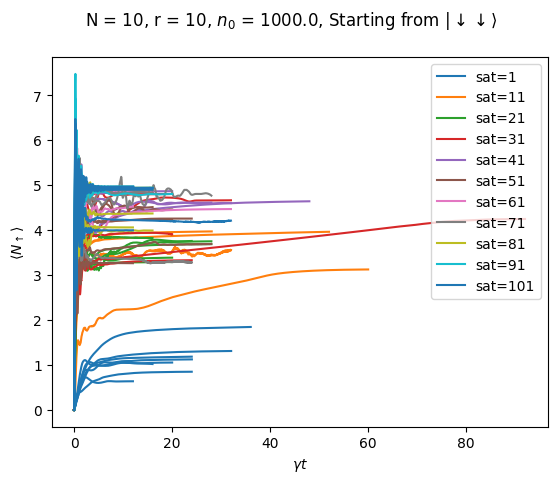

In [51]:
close("all")
fig, ax = subplots()
list_t_N, popup_t_N, nbr_error_t_N, sol_t_N = [], [], [], []

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    @load "solutions/sol_N_$(N)_r_$(r)_sat_$(s)_n0_$n0.jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(nbr_error_t_N, nbr_error), push!(sol_t_N, sol_t)
    for j in 1:length(popup_t)
        if j ∉ nbr_error
            if line == []
                line, = ax.plot(list_t[j], popup_t[j], label="sat=$(s)") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t[j], popup_t[j], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  N_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

0.0%┣                                               ┫ 0/11 [00:00<00:00, -0s/it]
100.0%┣███████████████████████████████████████████┫ 11/11 [00:00<00:00, 245it/s]
100.0%┣███████████████████████████████████████████┫ 11/11 [00:00<00:00, 235it/s]


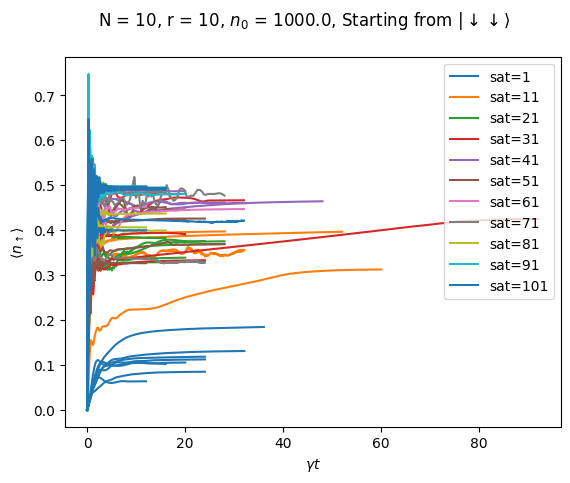

In [52]:
close("all")
fig, ax = subplots()

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    for j in 1:10#length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, label="sat=$(s)") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Mean of the SS

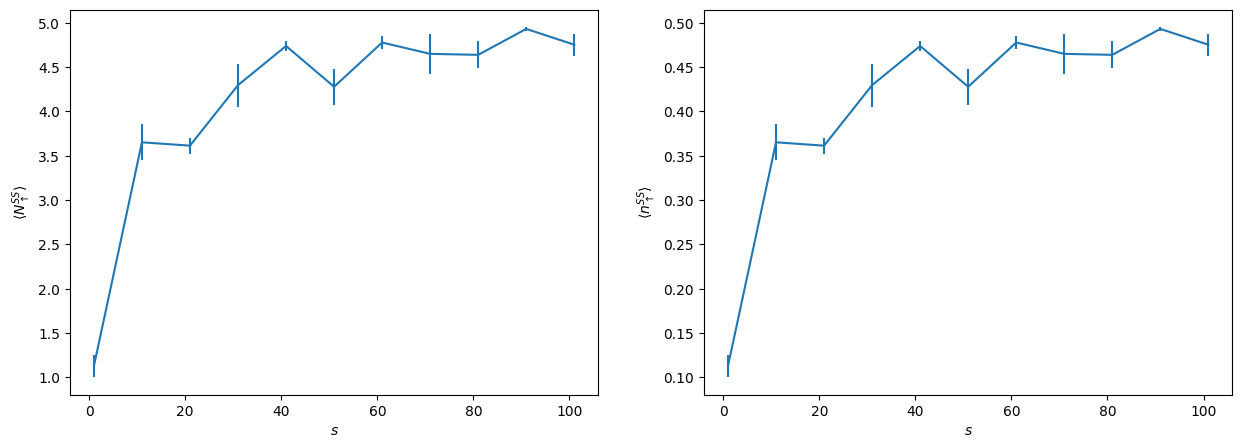

In [53]:
# For sat = 0, only throws errors as density to close from 0 --> remove the errors 
if 0 ∈ sat
    idx = findall(sat .== 0)[1]
    for i in 1:length(nbr_error_t_N[idx])
        if maximum(abs.(popup_t_N[idx][nbr_error_t_N[idx][i]])) < 10
            nbr_error_t_N[idx][i] = 0 # Physical solution
        end
    end
end

mean_SS = mean.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i]) if j ∉ nbr_error_t_N[i]] for i = 1:length(popup_t_N)])
std_SS = std.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i]) if j∉nbr_error_t_N[i]] for i = 1:length(popup_t_N)])

fig, axes = subplots(1, 2, figsize = (15, 5))
axes[1].errorbar(sat, mean_SS, yerr=std_SS ./ sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(sat)]))
axes[1].set_xlabel(L"s")
axes[1].set_ylabel(L"$\langle  N_{\uparrow}^{SS} \rangle $")

axes[2].errorbar(sat, mean_SS./N, yerr=std_SS ./ (N .* sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(sat)])))
axes[2].set_xlabel(L"s")
axes[2].set_ylabel(L"$\langle  n_{\uparrow}^{SS} \rangle $")


pygui(false); gcf();
# pygui(true); show()

# Compute a decay rate from the $\Gamma$ matrix

In [54]:
decay_rate_interactions_Gamma_matrix = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)
    @load "op_list/op_list_$N.jdl2" op_list

    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            @load "r0/r0_N_$(N)_r_$j.jdl2" r0 L
            system = SpinCollection(r0, e, gammas=1.)
            Γ_CS = GammaMatrix(system)
            
            if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
                sol_SS = sol_t_N[i][j][end]
            else
                sol_SS = sol_t_N[i][j] # Only the SS was saved
            end

            for a = 1:N
                for b = 1:N
                    if a == b
                        decay_rate_interactions_Gamma_matrix[i, j] += Γ_CS[a, a]*sol_SS[a]
                    end
                    if b > a
                        # corr = [21*10^(floor(Int, log10(a))+1)+a, 12*10^(floor(Int, log10(b))+1)+b]
                        corr = [22*10^(floor(Int, log10(a))+1)+a, 22*10^(floor(Int, log10(b))+1)+b]
                        try
                            decay_rate_interactions_Gamma_matrix[i, j] += 2*Γ_CS[a, b]*sol_SS[findall(x->x==corr || x==reverse(corr), op_list)[1]]
                        catch
                            println("Error @ $N, r=$j, a=$a, b=$b, corr=$corr")
                        end
                    end
                end
            end
        end
    end
end
decay_rate_interactions_Gamma_matrix

11×10 Matrix{ComplexF64}:
 0.797876+2.80229e-17im  4.32936-4.8699e-17im   …  1.89874+1.19956e-17im
      0.0+0.0im          15.3338-2.79771e-16im     9.82059-1.72519e-16im
      0.0+0.0im          14.9168+1.90988e-19im     13.9678+2.01671e-17im
      0.0+0.0im          17.9243-6.20515e-15im     21.8507+5.54077e-16im
      0.0+0.0im          23.4233-1.12631e-16im         0.0+0.0im
   13.922+3.58248e-16im  23.9506+2.04525e-17im  …  17.8103-1.29721e-16im
  22.7271+9.14453e-17im  23.4972+1.82401e-17im         0.0+0.0im
  23.2395+3.69556e-17im  23.9792+1.26225e-16im     22.2798+1.34686e-16im
   23.156+6.52287e-17im  24.2331-9.98195e-17im     16.8187+1.89661e-16im
  23.0905-2.53052e-16im  24.4278+1.6444e-16im      23.8478-3.89422e-16im
    22.78-8.0276e-19im   18.0082+2.0023e-16im   …      0.0+0.0im

In [55]:
decay_rate_interactions_Gamma_matrix = real.(decay_rate_interactions_Gamma_matrix)

11×10 Matrix{Float64}:
  0.797876   4.32936   0.0      0.0     …   1.68049   2.4895   1.89874
  0.0       15.3338    0.0      0.0        15.2326    0.0      9.82059
  0.0       14.9168   11.0882  13.1751      0.0       0.0     13.9678
  0.0       17.9243   14.9117  22.2316     20.3091    0.0     21.8507
  0.0       23.4233   19.8516   0.0         0.0      23.1296   0.0
 13.922     23.9506    0.0     10.5778  …   0.0      18.2421  17.8103
 22.7271    23.4972   23.0764   0.0        18.9885   20.5068   0.0
 23.2395    23.9792    0.0      0.0         0.0      23.5608  22.2798
 23.156     24.2331   23.5186   0.0        22.7583   19.3055  16.8187
 23.0905    24.4278   21.9224  23.2864      0.0      24.1927  23.8478
 22.78      18.0082   16.0906  23.3525  …  22.9803   24.2411   0.0

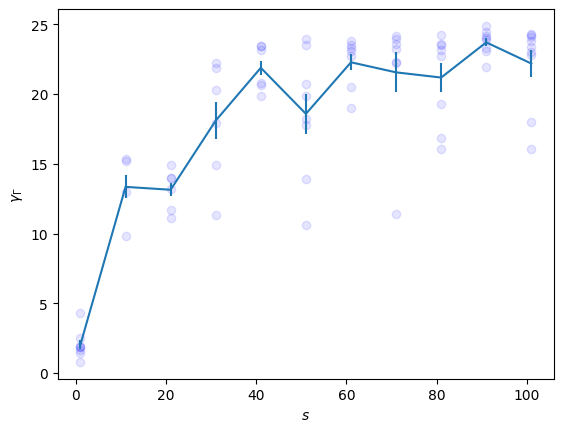

In [56]:
close("all")
fig = subplots()

errorbar(sat, [mean([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], decay_rate_interactions_Gamma_matrix[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"$\gamma_\Gamma$")
# pygui(true); show()
pygui(false);

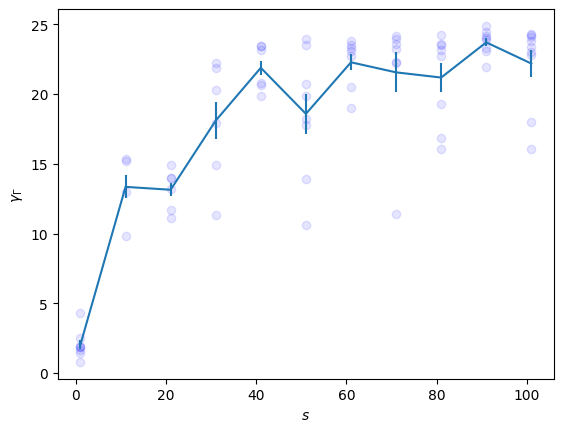

In [57]:
close("all")
fig = subplots()

errorbar(sat, [mean([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], decay_rate_interactions_Gamma_matrix[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"$\gamma_\Gamma$")
# pygui(true); show()
pygui(false);

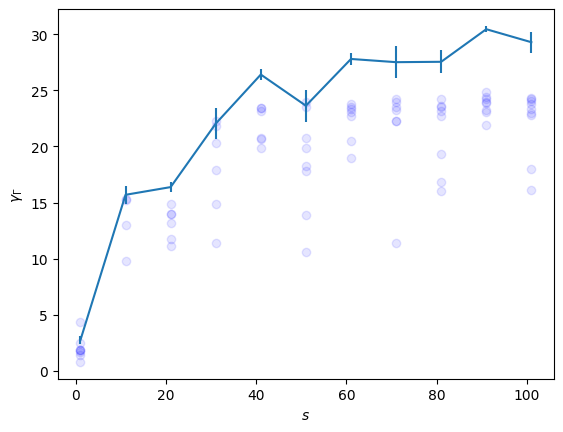

In [59]:
close("all")
fig = subplots()

errorbar(sat, [mean([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)]+Ω_RO, yerr=[std([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], decay_rate_interactions_Gamma_matrix[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"$\gamma_\Gamma$")
# pygui(true); show()
pygui(false);